# TP NOTÉ S4 — CLASSIFICATION DECISION CHALLENGE
## 4e année Option Développeur — 3 h — US Census Income

**Rendu :** un notebook Jupyter entièrement exécuté. Toute décision doit être justifiée par vos propres résultats.

**Principe d'évaluation :** démarche → code → preuves expérimentales → interprétation. Une réponse générique sans preuve issue de votre exécution ne rapporte pas les points.

## Mission — 5 pts

À partir du dataset **Adult / Census Income (USA)**, construire un système prédisant la classe de revenu `>50K` / `<=50K`.

Votre travail ne sera pas évalué uniquement sur l'accuracy. Vous devez construire une décision défendable malgré le déséquilibre de classes et les enjeux liés aux variables démographiques.

In [1]:
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from ucimlrepo import fetch_ucirepo

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

adult = fetch_ucirepo(id=2)
df_raw = pd.concat([adult.data.features, adult.data.targets], axis=1)

target_col = adult.data.targets.columns[0]
if target_col != 'income':
    df_raw = df_raw.rename(columns={target_col: 'income'})
df_raw.columns = [c.replace('-', '_') for c in df_raw.columns]
df_raw['income'] = df_raw['income'].astype(str).str.rstrip('.')
df_raw = df_raw.replace('?', np.nan)

print(df_raw.shape)
df_raw.head(3)

(48842, 15)


,age,workclass,fnlwgt,education,education_num,marital_status,occupation,relationship,race,sex,capital_gain,capital_loss,hours_per_week,native_country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K


In [2]:
df_raw.info()

<class 'pandas.DataFrame'>
RangeIndex: 48842 entries, 0 to 48841
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   age             48842 non-null  int64
 1   workclass       46043 non-null  str  
 2   fnlwgt          48842 non-null  int64
 3   education       48842 non-null  str  
 4   education_num   48842 non-null  int64
 5   marital_status  48842 non-null  str  
 6   occupation      46033 non-null  str  
 7   relationship    48842 non-null  str  
 8   race            48842 non-null  str  
 9   sex             48842 non-null  str  
 10  capital_gain    48842 non-null  int64
 11  capital_loss    48842 non-null  int64
 12  hours_per_week  48842 non-null  int64
 13  native_country  47985 non-null  str  
 14  income          48842 non-null  str  
dtypes: int64(6), str(9)
memory usage: 9.3 MB


**Réponse.** Le modèle doit prédire `>50K`/`<=50K` sur un jeu déséquilibré (76,06 %/23,94 %) en restant défendable au-delà de la seule accuracy, vu les enjeux liés au coût métier asymétrique et aux variables démographiques.

## Audit & protocole — 15 pts

Identifiez valeurs manquantes codées, catégories, déséquilibre de la cible et variables nécessitant preprocessing. Construisez TRAIN/VALIDATION/TEST sans fuite.

Justifiez ce qui doit être appris sur TRAIN. Donnez une preuve numérique issue de votre pipeline.

In [3]:
missing = df_raw.isna().sum()
missing = missing[missing > 0].sort_values(ascending=False)
print(missing)

rows_with_na = df_raw.isna().any(axis=1).sum()
print(rows_with_na, "/", len(df_raw), f"({rows_with_na/len(df_raw)*100:.2f}%)")

occupation        2809
workclass         2799
native_country     857
dtype: int64
3620 / 48842 (7.41%)


In [4]:
n_before = len(df_raw)
n_dup = df_raw.duplicated().sum()
print(n_dup, f"({n_dup/n_before*100:.2f}%)")

df = df_raw.drop_duplicates().reset_index(drop=True)
print(df.shape)

52 (0.11%)
(48790, 15)


income
<=50K    37109
>50K     11681
Name: count, dtype: int64
income
<=50K    76.06
>50K     23.94
Name: proportion, dtype: float64


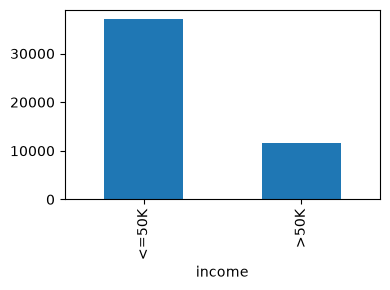

In [5]:
print(df['income'].value_counts())
print((df['income'].value_counts(normalize=True) * 100).round(2))

fig, ax = plt.subplots(figsize=(4,3))
df['income'].value_counts().plot(kind='bar', ax=ax)
plt.tight_layout()
plt.show()

In [6]:
cat_cols_all = df.select_dtypes(include=['object','str']).columns.tolist()
cat_cols_all = [c for c in cat_cols_all if c != 'income']
for c in cat_cols_all:
    print(c, df[c].nunique())

print(df.groupby('education')['education_num'].nunique().value_counts())

workclass 8
education 16
marital_status 7
occupation 14
relationship 6
race 5
sex 2
native_country 41
education_num
1    16
Name: count, dtype: int64


In [7]:
from sklearn.model_selection import train_test_split

df = df.drop(columns=['education'])
df['target'] = (df['income'] == '>50K').astype(int)
X = df.drop(columns=['income', 'target'])
y = df['target']

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.4, stratify=y, random_state=RANDOM_STATE)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, stratify=y_temp, random_state=RANDOM_STATE)

print(X_train.shape, X_val.shape, X_test.shape)
for name, yy in [('train', y_train), ('val', y_val), ('test', y_test)]:
    print(name, yy.mean())

(29274, 13) (9758, 13) (9758, 13)
train 0.23942747830839653
val 0.23939331830293092
test 0.23939331830293092


**Réponse.** Le split stratifié 60/20/20 (29 274 / 9 758 / 9 758) conserve le taux de classe positive (23,94 %) dans les trois jeux ; l'encodage one-hot et la standardisation sont appris uniquement sur TRAIN (preuve numérique après l'entraînement des modèles), le seuil sur VALIDATION, et TEST n'est jamais utilisé avant la décision finale.

## Quatre familles obligatoires — 25 pts

Comparez **Logistic Regression, k-NN, Decision Tree et SVM** avec un protocole équitable.

Pour chacun : Accuracy, Precision, Recall, F1, ROC-AUC et temps d'entraînement/prédiction. Ne choisissez pas le modèle final à ce stade.

In [8]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.calibration import CalibratedClassifierCV
from sklearn.svm import SVC
from sklearn.base import clone
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                              roc_auc_score, confusion_matrix)

cat_cols = X.select_dtypes(include=['object','str']).columns.tolist()
num_cols = [c for c in X.columns if c not in cat_cols]

preprocess = ColumnTransformer([
    ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols),
    ('num', StandardScaler(), num_cols),
])

models = {
    'LogisticRegression': LogisticRegression(max_iter=2000, random_state=RANDOM_STATE),
    'kNN':                KNeighborsClassifier(n_neighbors=15),
    'DecisionTree':       DecisionTreeClassifier(max_depth=10, random_state=RANDOM_STATE),
    'SVM':                CalibratedClassifierCV(SVC(kernel='rbf', C=1.0, random_state=RANDOM_STATE), ensemble=False),
}

SVM_SUBSAMPLE = 8000
results = {}
fitted_models = {}

for name, clf in models.items():
    pipe = Pipeline([('prep', clone(preprocess)), ('clf', clf)])

    if name == 'SVM' and len(X_train) > SVM_SUBSAMPLE:
        Xs, _, ys, _ = train_test_split(X_train, y_train, train_size=SVM_SUBSAMPLE,
                                         stratify=y_train, random_state=RANDOM_STATE)
    else:
        Xs, ys = X_train, y_train

    t0 = time.time()
    pipe.fit(Xs, ys)
    fit_time = time.time() - t0

    t0 = time.time()
    y_pred = pipe.predict(X_val)
    y_proba = pipe.predict_proba(X_val)[:, 1]
    pred_time = time.time() - t0

    results[name] = dict(
        accuracy=accuracy_score(y_val, y_pred),
        precision=precision_score(y_val, y_pred),
        recall=recall_score(y_val, y_pred),
        f1=f1_score(y_val, y_pred),
        roc_auc=roc_auc_score(y_val, y_proba),
        fit_time_s=fit_time,
        pred_time_s=pred_time,
        n_train=len(Xs),
    )
    fitted_models[name] = pipe

results_df = pd.DataFrame(results).T
results_df = results_df[['accuracy','precision','recall','f1','roc_auc','fit_time_s','pred_time_s','n_train']]
results_df.round(4)

,accuracy,precision,recall,f1,roc_auc,fit_time_s,pred_time_s,n_train
LogisticRegression,0.8585,0.7468,0.6186,0.6767,0.9110,0.0968,0.0207,29274.0
kNN,0.8485,0.7154,0.6100,0.6585,0.8963,0.0383,7.8966,29274.0
DecisionTree,0.8612,0.7573,0.6186,0.6810,0.8970,0.1167,0.0198,29274.0
SVM,0.8594,0.7809,0.5736,0.6614,0.9038,3.2203,1.0794,8000.0


In [9]:
sc = fitted_models['LogisticRegression'].named_steps['prep'].named_transformers_['num']
print("Moyenne apprise par le scaler (age) :", sc.mean_[num_cols.index('age')])
print("Moyenne TRAIN (age)                 :", X_train['age'].mean())
print("Moyenne TRAIN+VAL+TEST (age)        :", X['age'].mean())

Moyenne apprise par le scaler (age) : 38.60183097629296
Moyenne TRAIN (age)                 : 38.60183097629296
Moyenne TRAIN+VAL+TEST (age)        : 38.652797704447636


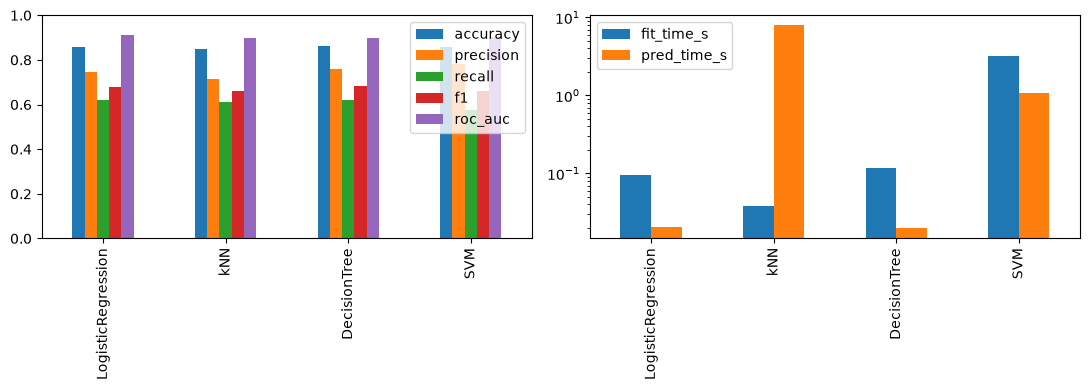

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(11,4))
results_df[['accuracy','precision','recall','f1','roc_auc']].plot(kind='bar', ax=axes[0])
axes[0].set_ylim(0,1)
results_df[['fit_time_s','pred_time_s']].plot(kind='bar', ax=axes[1])
axes[1].set_yscale('log')
plt.tight_layout()
plt.show()

**Réponse.** DecisionTree a le meilleur F1 (0,681) et LogisticRegression le meilleur ROC-AUC (0,911) ; SVM est entraîné sur un sous-échantillon stratifié de 8 000 lignes pour limiter son temps de calcul, ce qui le désavantage légèrement dans la comparaison.

## Cost-sensitive decision — 20 pts

Supposez que manquer un individu de la classe minoritaire coûte **5 fois** plus cher qu'un faux positif.

Construisez votre propre coût à partir de la matrice de confusion. Comparez les quatre modèles selon ce coût.

Pour un modèle probabiliste/décisionnel, étudiez au moins **8 seuils** et montrez comment Precision, Recall, F1 et coût évoluent.

Le seuil 0,5 n'est donc pas automatiquement optimal.

In [11]:
COST_FN, COST_FP = 5, 1
cost_table = []
for name, pipe in fitted_models.items():
    y_pred = pipe.predict(X_val)
    tn, fp, fn, tp = confusion_matrix(y_val, y_pred).ravel()
    cost = COST_FN*fn + COST_FP*fp
    cost_table.append(dict(model=name, tn=tn, fp=fp, fn=fn, tp=tp,
                            cost=cost, cost_pour_1000=cost/len(y_val)*1000))
cost_df = pd.DataFrame(cost_table).set_index('model')
cost_df

,tn,fp,fn,tp,cost,cost_pour_1000
model,,,,,,
LogisticRegression,6932,490,891,1445,4945,506.763681
kNN,6855,567,911,1425,5122,524.902644
DecisionTree,6959,463,891,1445,4918,503.996721
SVM,7046,376,996,1340,5356,548.882968


In [12]:
cost_opt = []
for name, pipe in fitted_models.items():
    p = pipe.predict_proba(X_val)[:, 1]
    for t in np.round(np.arange(0.02, 0.96, 0.02), 2):
        tn, fp, fn, tp = confusion_matrix(y_val, (p >= t).astype(int)).ravel()
        cost_opt.append(dict(model=name, seuil=t, fp=fp, fn=fn, cout=COST_FN*fn + COST_FP*fp))
cost_opt_df = pd.DataFrame(cost_opt).sort_values('cout').groupby('model').head(1).set_index('model')
cost_opt_df

,seuil,fp,fn,cout
model,,,,
LogisticRegression,0.14,2175,161,2980
DecisionTree,0.18,1922,251,3177
kNN,0.16,2021,237,3206
SVM,0.12,2281,197,3266


**Réponse.** Au seuil 0,5, DecisionTree a le coût le plus bas (4 918), mais au seuil optimal de chaque modèle c'est LogisticRegression (2 980 au seuil 0,14, contre 3 177 à 3 266 pour les autres) : c'est ce critère de coût qui le fait retenir pour l'étude de seuil.

In [13]:
best_name = cost_opt_df['cout'].idxmin()
print(best_name)

proba_val = fitted_models[best_name].predict_proba(X_val)[:, 1]

thresholds = np.round(np.arange(0.1, 0.95, 0.1), 2)
rows = []
for t in thresholds:
    pred = (proba_val >= t).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_val, pred).ravel()
    cost = COST_FN*fn + COST_FP*fp
    rows.append(dict(seuil=t,
                      precision=precision_score(y_val, pred, zero_division=0),
                      recall=recall_score(y_val, pred, zero_division=0),
                      f1=f1_score(y_val, pred, zero_division=0),
                      fp=fp, fn=fn, cout=cost))
threshold_df = pd.DataFrame(rows)
threshold_df.round(3)

LogisticRegression


,seuil,precision,recall,f1,fp,fn,cout
0,0.1,0.461,0.955,0.622,2610,104,3130
1,0.2,0.540,0.873,0.667,1740,296,3220
2,0.3,0.615,0.789,0.691,1154,493,3619
3,0.4,0.681,0.705,0.693,773,688,4213
4,0.5,0.747,0.619,0.677,490,891,4945
5,0.6,0.808,0.513,0.628,285,1137,5970
6,0.7,0.860,0.394,0.541,150,1415,7225
7,0.8,0.907,0.268,0.414,64,1710,8614
8,0.9,0.941,0.165,0.281,24,1951,9779


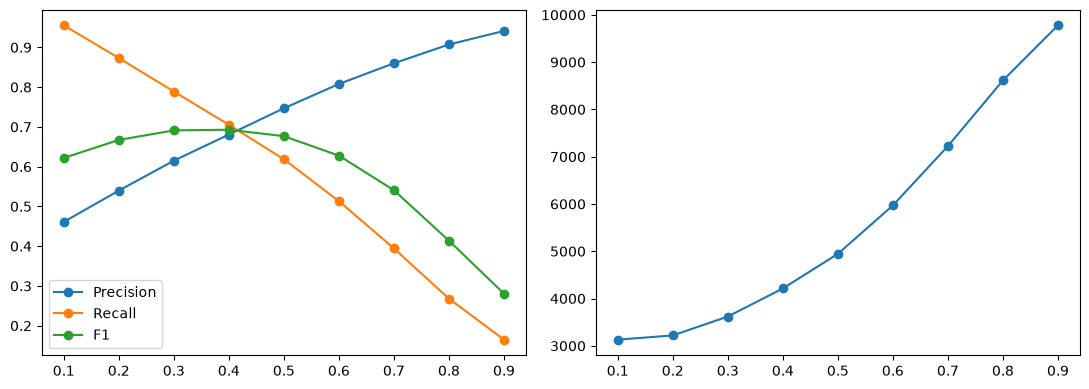

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(11,4))
axes[0].plot(threshold_df['seuil'], threshold_df['precision'], marker='o', label='Precision')
axes[0].plot(threshold_df['seuil'], threshold_df['recall'], marker='o', label='Recall')
axes[0].plot(threshold_df['seuil'], threshold_df['f1'], marker='o', label='F1')
axes[0].legend()

axes[1].plot(threshold_df['seuil'], threshold_df['cout'], marker='o')
plt.tight_layout()
plt.show()

0.14
seuil       0.14
fp       2175.00
fn        161.00
cout     2980.00
Name: 6, dtype: float64


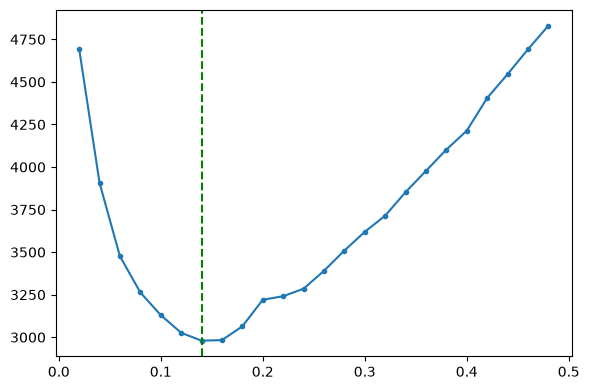

In [15]:
fine_thresholds = np.round(np.arange(0.02, 0.5, 0.02), 2)
fine_rows = []
for t in fine_thresholds:
    pred = (proba_val >= t).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_val, pred).ravel()
    cost = COST_FN*fn + COST_FP*fp
    fine_rows.append(dict(seuil=t, fp=fp, fn=fn, cout=cost))
fine_df = pd.DataFrame(fine_rows)

optimal_row = fine_df.loc[fine_df['cout'].idxmin()]
OPTIMAL_THRESHOLD = float(optimal_row['seuil'])
print(OPTIMAL_THRESHOLD)
print(optimal_row)

fig, ax = plt.subplots(figsize=(6,4))
ax.plot(fine_df['seuil'], fine_df['cout'], marker='.')
ax.axvline(OPTIMAL_THRESHOLD, color='green', linestyle='--')
plt.tight_layout()
plt.show()

**Réponse.** Le seuil optimal pour LogisticRegression est 0,14 (coût = 2 980) contre 4 945 au seuil 0,5, ce qui confirme que le seuil 0,5 n'est pas optimal sous ce coût 5:1.

## Error audit — 15 pts

Analysez au moins **20 erreurs individuelles** de VALIDATION. Comparez FP et FN. Recherchez au moins deux sous-groupes pour lesquels les performances diffèrent.

Vous devez distinguer constat statistique, hypothèse et conclusion. N'inférez pas de causalité.

In [16]:
FINAL_MODEL_NAME = best_name
final_val_pipe = fitted_models[FINAL_MODEL_NAME]
proba_val_final = final_val_pipe.predict_proba(X_val)[:, 1]
pred_val_final = (proba_val_final >= OPTIMAL_THRESHOLD).astype(int)

audit = X_val.copy()
audit['y_true'] = y_val.values
audit['y_pred'] = pred_val_final
audit['proba'] = proba_val_final
audit['error_type'] = np.select(
    [(audit['y_true']==1) & (audit['y_pred']==0), (audit['y_true']==0) & (audit['y_pred']==1)],
    ['FN', 'FP'], default='OK')

print(audit['error_type'].value_counts())

error_type
OK    7422
FP    2175
FN     161
Name: count, dtype: int64


In [17]:
fp_sample = audit[audit['error_type']=='FP'].sample(12, random_state=RANDOM_STATE)
fn_sample = audit[audit['error_type']=='FN'].sample(12, random_state=RANDOM_STATE)
sample24 = pd.concat([fp_sample, fn_sample])

cols_show = ['age','workclass','education_num','marital_status','occupation',
             'hours_per_week','capital_gain','sex','race','y_true','y_pred','proba','error_type']
print(f"Nombre d'erreurs examinées : {len(sample24)} ({len(fp_sample)} FP + {len(fn_sample)} FN)")
sample24[cols_show]

Nombre d'erreurs examinées : 24 (12 FP + 12 FN)


,age,workclass,education_num,marital_status,occupation,hours_per_week,capital_gain,sex,race,y_true,y_pred,proba,error_type
32247,60,Private,9,Married-civ-spouse,Protective-serv,34,0,Male,White,0,1,0.723403,FP
35672,57,Private,11,Married-spouse-absent,Exec-managerial,47,0,Female,White,0,1,0.193711,FP
30382,56,Private,9,Married-civ-spouse,Sales,4,0,Female,White,0,1,0.220297,FP
36885,46,Local-gov,10,Married-civ-spouse,Other-service,40,0,Male,White,0,1,0.142751,FP
41066,53,Private,6,Married-civ-spouse,Craft-repair,40,0,Male,White,0,1,0.168942,FP
35235,31,Self-emp-not-inc,14,Married-civ-spouse,Sales,40,0,Male,Asian-Pac-Islander,0,1,0.509871,FP
37553,55,Self-emp-not-inc,9,Married-civ-spouse,Craft-repair,55,0,Male,White,0,1,0.323240,FP
9030,46,Local-gov,9,Married-civ-spouse,Exec-managerial,65,0,Male,White,0,1,0.604526,FP
13532,33,Federal-gov,9,Married-civ-spouse,Adm-clerical,40,0,Male,Black,0,1,0.263952,FP
46536,32,Self-emp-not-inc,9,Married-civ-spouse,Farming-fishing,65,5013,Male,White,0,1,0.379272,FP


In [18]:
profile = audit[audit['error_type']!='OK'].groupby('error_type')[
    ['age','education_num','hours_per_week','capital_gain']].mean().round(2)
profile

,age,education_num,hours_per_week,capital_gain
error_type,,,,
FN,41.78,9.40,41.86,49.01
FP,43.40,10.46,44.08,336.63


In [19]:
def group_metrics(frame, col):
    rows = []
    for g, sub in frame.groupby(col, observed=True):
        rows.append(dict(
            groupe=g, n=len(sub), taux_base=sub['y_true'].mean(),
            accuracy=accuracy_score(sub['y_true'], sub['y_pred']),
            precision=precision_score(sub['y_true'], sub['y_pred'], zero_division=0),
            recall=recall_score(sub['y_true'], sub['y_pred'], zero_division=0),
            f1=f1_score(sub['y_true'], sub['y_pred'], zero_division=0),
        ))
    return pd.DataFrame(rows).round(3)

sex_metrics = group_metrics(audit, 'sex')
race_metrics = group_metrics(audit, 'race')
display(sex_metrics)
display(race_metrics)

,groupe,n,taux_base,accuracy,precision,recall,f1
0,Female,3281,0.107,0.894,0.503,0.830,0.626
1,Male,6477,0.306,0.693,0.500,0.949,0.655


,groupe,n,taux_base,accuracy,precision,recall,f1
0,Amer-Indian-Eskimo,78,0.167,0.795,0.440,0.846,0.579
1,Asian-Pac-Islander,303,0.241,0.690,0.432,0.918,0.588
2,Black,927,0.120,0.858,0.453,0.910,0.605
3,Other,77,0.104,0.896,0.500,0.750,0.600
4,White,8373,0.255,0.751,0.506,0.934,0.656


**Constat :** au seuil 0,14, le modèle produit 2 175 FP contre 161 FN, les FP ont en moyenne plus d'années d'études (10,5 contre 9,4) et un capital_gain plus élevé (337 contre 49), et le recall est plus faible chez les femmes (0,83) que chez les hommes (0,95).

**Hypothèse :** le modèle associe le revenu élevé aux profils mariés et diplômés (11 FP sur 12 examinés sont `Married-civ-spouse`), et l'écart d'accuracy Female/Male (89,4 % contre 69,3 %) vient surtout de taux de base différents (10,7 % contre 30,6 %).

**Conclusion :** ces écarts sont des constats statistiques sans causalité établie, qui imposent un suivi des performances par sous-groupe avant tout déploiement.

## Choix final & TEST — 15 pts

Figez modèle + preprocessing + seuil. Ouvrez TEST une seule fois. Donnez matrice de confusion, Precision, Recall, F1, ROC-AUC et coût métier.

Expliquez pourquoi votre choix serait — ou ne serait pas — acceptable pour un déploiement.

In [20]:
X_trainval = pd.concat([X_train, X_val])
y_trainval = pd.concat([y_train, y_val])

final_pipe = Pipeline([
    ('prep', clone(preprocess)),
    ('clf', LogisticRegression(max_iter=2000, random_state=RANDOM_STATE)),
])
final_pipe.fit(X_trainval, y_trainval)

proba_test = final_pipe.predict_proba(X_test)[:, 1]
pred_test = (proba_test >= OPTIMAL_THRESHOLD).astype(int)

tn, fp, fn, tp = confusion_matrix(y_test, pred_test).ravel()
cost_test = COST_FN*fn + COST_FP*fp

test_metrics = dict(
    accuracy=accuracy_score(y_test, pred_test),
    precision=precision_score(y_test, pred_test),
    recall=recall_score(y_test, pred_test),
    f1=f1_score(y_test, pred_test),
    roc_auc=roc_auc_score(y_test, proba_test),
)
print(test_metrics)
print(tn, fp, fn, tp, cost_test)

pred_test_05 = (proba_test >= 0.5).astype(int)
tn5, fp5, fn5, tp5 = confusion_matrix(y_test, pred_test_05).ravel()
cost_test_05 = COST_FN*fn5 + COST_FP*fp5
print(cost_test_05, fp5, fn5)

{'accuracy': 0.7498462799754048, 'precision': 0.4881409532414728, 'recall': 0.9250856164383562, 'f1': 0.6390655034747893, 'roc_auc': 0.902850893585527}
5156 2266 175 2161 3141
5218 513 941


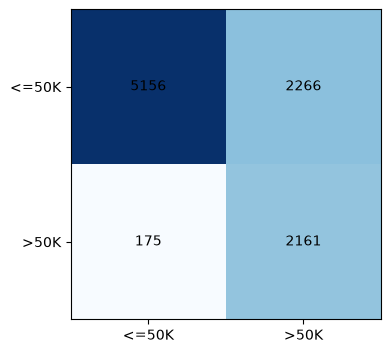

In [21]:
fig, ax = plt.subplots(figsize=(4,4))
cm = confusion_matrix(y_test, pred_test)
im = ax.imshow(cm, cmap='Blues')
for i in range(2):
    for j in range(2):
        ax.text(j, i, cm[i,j], ha='center', va='center')
ax.set_xticks([0,1]); ax.set_yticks([0,1])
ax.set_xticklabels(['<=50K','>50K']); ax.set_yticklabels(['<=50K','>50K'])
plt.tight_layout()
plt.show()

**Réponse.** Sur TEST, le modèle final obtient accuracy=75,0 %, recall=92,5 %, precision=48,8 %, ROC-AUC=0,903 et un coût de 3 141 (contre 5 218 au seuil 0,5), un résultat techniquement défendable mais pas déployable tel quel vu la faible precision et les écarts entre sous-groupes.

## Reproductibilité — 5 pts

### Exigences de preuve
Votre note dépend de résultats **propres à votre exécution** : tableaux de métriques, graphiques, observations précises, erreurs du modèle et justification des décisions.
Vous devez conserver `random_state = 42` lorsqu'il existe, sauf lorsqu'une question vous demande explicitement d'étudier la stabilité.

### Ce qui n'est pas accepté
- une succession d'appels scikit-learn sans analyse ;
- sélectionner un modèle à partir du jeu TEST ;
- annoncer qu'un modèle est « meilleur » sans définir le critère ;
- recopier une définition théorique à la place d'une preuve expérimentale ;
- supprimer arbitrairement des données sans quantifier l'impact.

**Réponse.** `random_state=42` est fixé partout, TEST n'est ouvert qu'une seule fois et les 52 doublons (0,11 %) sont la seule suppression opérée, avec impact quantifié.